In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pylab as plt
import glob
import os
import shutil
from pprint import pprint
import zipfile

In [3]:
import stephane.display.graphes as graphes
import stephane.tools.Smath as smath


import icewave.phone.analyse as analyse

import scipy.signal as sig

Linux
adour


In [4]:
def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

In [14]:
date = '2025_1023'
year,day = date.split('_')

phonelist = range(10,27)
base = f'/media/turbots/DATA/thiou/labshared2/Projet_E/SdB/{day}/Phones/'
savefolder = base +'Results/'
if not os.path.exists(savefolder):
    os.makedirs(savefolder)

folderlist = glob.glob(base+'*/')
folderlist = [os.path.basename(folder[:-1]) for folder in folderlist]
folderlist.remove('Results')
folderlist.remove('Tsync')
#folderlist.remove('FP4_00')

#pprint(folderlist)
phonelist = folderlist
datas={}

L = 9.03
n = len(phonelist)-1
for i,phone in enumerate(folderlist):
    try:
        phone = int(phone)
    except:
        print('Not an int')
    datafolder = base+f'{phone}/'#+ 'FP4_00/'
    filelist = glob.glob(datafolder+'*accelerometer*.csv')
    print(phone,len(filelist))
    datas[phone]={}
    datas[phone]['files']=filelist
    datas[phone]['x']=(n-i)*L

1 6
7 14
39 12
4 14
10 9
64 2
62 14
50 10
2 14
9 13
40 14
22 16
12 14
56 10
44 14
24 23
Not an int
FP4_00 13
60 14
15 14
63 20
30 14
57 14
49 10
54 12
8 12
46 20
21 12
36 12
51 5
58 13
23 23
47 15
45 14
11 10
17 15
42 9
61 14
55 14
20 14
37 13
0 22
52 5
14 14
13 14
6 14
53 14
5 23
41 17
59 14
16 14
43 14
19 14
18 14
31 8
32 7
35 13
34 12
33 14
38 14
27 23
26 23
48 19
25 23


In [15]:
key = int(datas[phone]['files'][0].split('accelerometer-')[1].split('-')[0])
print(key)

13


In [16]:
import icewave.tools.rw_data as rw
import icewave.phone.load as load_phone

for phone in datas.keys():
    datas[phone]['d']={}
    print(phone)
    for j,filename in enumerate(datas[phone]['files']):
        key = int(filename.split('accelerometer-')[1].split('-')[0])
        print(key)
        if key>=13:
            continue
        try:
            data = load_phone.load_gobfile(filename,var='a')
        except:
            print('deso',phone,key)
        datas[phone]['d'][key]=data

1
1
6
5
4
3
2
7
10
2
3
6
14
13
9
5
12
7
1
8
11
4
39
12
10
2
8
4
7
6
1
5
3
9
11
4
10
13
9
11
2
14
4
3
1
5
8
7
12
6
10
10
6
7
2
9
5
4
3
8
64
2
1
62
3
7
13
4
1
5
11
8
9
10
6
2
12
14
50
6
deso 50 6
10
2
deso 50 2
9
deso 50 9
5
8
deso 50 8
7
deso 50 7
1
deso 50 1
3
4
deso 50 4
2
7
6
12
1
10
14
5
13
3
2
9
4
8
11
9
13
4
7
3
11
12
1
5
8
6
10
9
2
40
6
12
11
8
10
1
5
4
2
14
13
3
7
9
22
16
8
11
13
3
5
10
14
2
15
4
9
6
12
7
1
12
2
9
12
6
14
7
13
8
11
5
1
4
10
3
56
3
6
1
2
1
4
5
3
4
2
44
7
9
4
13
3
14
1
12
11
10
2
6
8
5
24
15
12
5
3
9
1
17
22
10
8
23
4
11
13
21
19
7
16
14
2
6
18
20
FP4_00
8
1
9
13
3
12
4
7
2
10
5
6
11
60
9
3
8
4
12
14
2
1
11
10
13
7
5
6
15
4
10
2
1
7
11
6
14
8
13
9
12
3
5
63
17
6
2
20
8
18
10
15
19
3
14
16
5
4
1
13
11
9
12
7
30
10
7
12
14
6
11
4
13
9
2
1
3
8
5
57
6
13
14
9
3
11
5
1
12
2
7
10
8
4
49
9
deso 49 9
10
7
6
8
4
3
5
2
1
deso 49 1
54
9
5
10
6
2
4
7
8
11
12
1
3
8
12
4
11
7
8
10
5
3
9
1
6
2
46
3
2
7
6
11
4
18
5
8
1
16
9
14
15
19
13
17
20
10
12
21
12
2
9
7
11
1
3
5
10
8
4
6
36

In [28]:
(np.max(t)-np.min(t))/3600

0.2486965925163693

In [22]:
datas[phone]['d'][7].keys()

dict_keys(['coords', 'ta', 'ax', 'ay', 'az'])

In [37]:
times = rw.read_csv(base+'Tsync/tsync_1761239295_good.txt')
times = rw.csv2dict(times)

In [38]:
for phone in datas.keys():
    datas[phone]['tlag']=times[str(phone)]['tlag']

In [47]:
for phone in datas.keys():
    print(phone,np.sort(list(datas[phone]['d'].keys())))

10 [ 2  3  4  5  6  7  8  9 10]
11 [ 2  3  4  5  6  7  8  9 10 11]
12 [ 1  2  3  4  5  6  7  8  9 10 11 12]
13 [ 1  2  3  4  5  6  7  8  9 10 11 12]
14 [ 1  2  3  4  5  6  7  8  9 10 11 12]
15 [ 1  2  3  4  5  6  7  8  9 10 11 12]
16 [ 1  2  3  4  5  6  7  8  9 10 11 12]
17 [ 1  2  3  4  5  6  7  8  9 10 11 12]
18 [ 1  2  3  4  5  6  7  8  9 10 11 12]
19 [ 1  2  3  4  5  6  7  8  9 10 11 12]
20 [ 1  2  3  4  5  6  7  8  9 10 11 12]
21 [ 1  2  3  4  5  6  7  8  9 10 11 12]
22 [ 1  2  3  4  5  6  7  8  9 10 11 12]
23 [ 1  2  3  4  5  6  7  8  9 10 11 12]
24 [ 1  2  3  4  5  6  7  8  9 10 11 12]
25 [ 1  2  3  4  5  6  7  8  9 10 11 12]
26 [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [163]:
t0=1761225137.2841012

import icewave.field.time as tf

tf.display_time(tf.today_time([t0]))[0]

tsmin = '14:45:00'
tsmax = '16:15:00'

tmin = tf.convert_time(tsmin)
tmax = tf.convert_time(tsmax)

print(tmin,tmax)
tmin = 53600
tmax = 59000

print((tmax-tmin)/3600)

52200 59400
1.5


10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


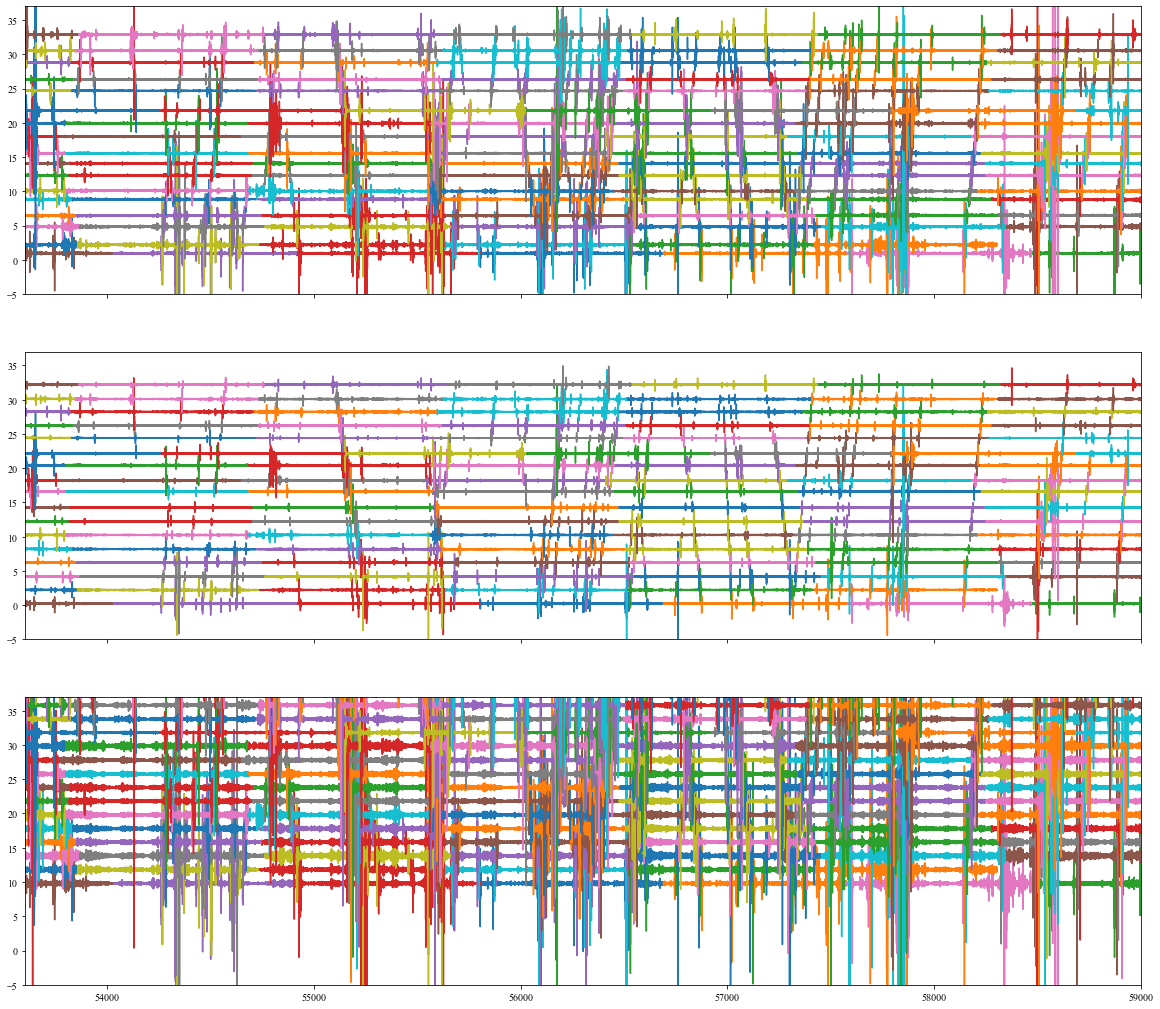

In [164]:

fig,axs = plt.subplots(figsize=(20,3*6),nrows=3,sharex=True)

datai={}

for i,phone in enumerate(datas.keys()):
    print(phone)
    datas[phone]['keys']=[]
    for key in datas[phone]['d'].keys():
        data = datas[phone]['d'][key]
        t = tf.today_time(data['ta']/10**6+datas[phone]['tlag'])
        if max(t)>tmin and min(t)<tmax:
            datas[phone]['keys'].append(key)
            for c,ax in zip(data['coords'],axs):
                ax.plot(t,data[var+c]+2*i)
                ax.set_ylim([-5,37])
                
    ax.set_xlim([tmin,tmax])

In [200]:
datai={}
import icewave.field.time as tf

var = 'a'
for i,phone in enumerate(datas.keys()):
    print(phone)
    datai[phone]={}
    datai[phone]['tas']=[]
    for c in coords:
        datai[phone][var+c]=[]
        
    for key in datas[phone]['keys']:
        data = datas[phone]['d'][key]
        t = np.asarray(tf.today_time(data['ta']/10**6+datas[phone]['tlag']))
        indices = np.logical_and(t>tmin-1,t<tmax+1)
        datai[phone]['tas']=datai[phone]['tas']+list(t[indices])
        for c in data['coords']:
            datai[phone][var+c]=datai[phone][var+c]+list(data[var+c][indices])

10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


In [173]:
for phone in datai.keys():
    print(np.min(datai[phone]['ta']))
    print(np.max(datai[phone]['ta']))


53599.00105
59000.999573
53599.002092
58304.029549
53599.00127
59000.99874
53599.002326
59000.998218
53599.001545
59000.997768
53599.002109
59000.999327
53599.002101
59000.998742
53599.001435
59000.999827
53599.000028
59000.998489
53599.000959
59000.999773
53599.002369
59000.999596
53599.000841
59000.998516
53599.001666
59000.999325
53599.000992
59000.999076
53599.000771
59000.997621
53599.00246
59000.998433
53599.000486
59000.99814


In [181]:

coords = datas[phone]['d'][9]["coords"]

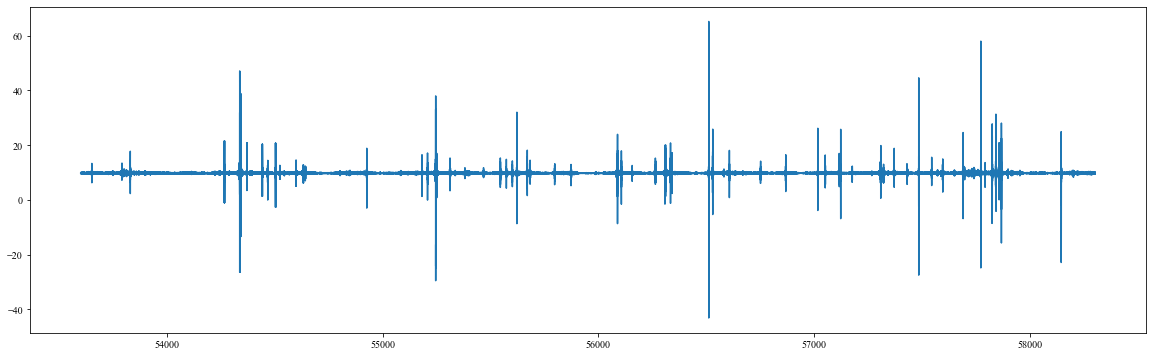

In [185]:
phone = 11
fig,ax = plt.subplots(figsize=(20,6))#,nrows=3,sharex=True)

ax.plot(datai[phone]['tas'],datai[phone]['az'])

In [201]:
import scipy.interpolate as interp

dt = 1/400
n = len(datai.keys())
M = np.zeros((n,len(ti),3))


for i,phone in enumerate(datai.keys()):
    data = datai[phone]
    t = data['tas']
    print(phone)
    print(np.min(t),np.max(t))
    for j,c in enumerate(coords):
        if c=='z':
            g=9.81
        else:
            g=0
        y = np.asarray(data[var+c])-g
        
        fi = interp.interp1d(t,y)
        t0 = np.max([tmin,np.min(t)])
        tf = np.min([tmax,np.max(t)])
        ti = np.arange(t0,tf,dt)
        M[i,:len(ti),j]=fi(ti)

print(M.shape)

10
53599.00105 59000.999573
11
53599.002092 58304.029549
12
53599.00127 59000.99874
13
53599.002326 59000.998218
14
53599.001545 59000.997768
15
53599.002109 59000.999327
16
53599.002101 59000.998742
17
53599.001435 59000.999827
18
53599.000028 59000.998489
19
53599.000959 59000.999773
20
53599.002369 59000.999596
21
53599.000841 59000.998516
22
53599.001666 59000.999325
23
53599.000992 59000.999076
24
53599.000771 59000.997621
25
53599.00246 59000.998433
26
53599.000486 59000.99814
(17, 2160000, 3)


In [159]:
for phone in datas.keys():
    keys = datas[phone]['keys']
    print(phone,len(keys),keys)

10 9 [10, 6, 7, 2, 9, 5, 4, 3, 8]
11 8 [7, 2, 9, 6, 11, 5, 10, 8]
12 8 [9, 12, 6, 7, 8, 11, 5, 10]
13 8 [6, 11, 5, 8, 7, 9, 10, 12]
14 8 [10, 6, 7, 9, 5, 11, 12, 8]
15 8 [10, 7, 11, 6, 8, 9, 12, 5]
16 8 [6, 7, 11, 9, 12, 8, 5, 10]
17 8 [12, 10, 9, 5, 8, 7, 11, 6]
18 8 [6, 9, 12, 5, 7, 11, 8, 10]
19 8 [6, 5, 9, 7, 12, 8, 10, 11]
20 8 [6, 12, 7, 5, 8, 10, 11, 9]
21 7 [9, 7, 11, 5, 10, 8, 6]
22 8 [8, 11, 5, 10, 9, 6, 12, 7]
23 8 [11, 6, 10, 9, 12, 8, 7, 5]
24 8 [12, 5, 9, 10, 8, 11, 7, 6]
25 8 [12, 7, 8, 5, 6, 9, 10, 11]
26 8 [11, 12, 8, 6, 5, 7, 9, 10]


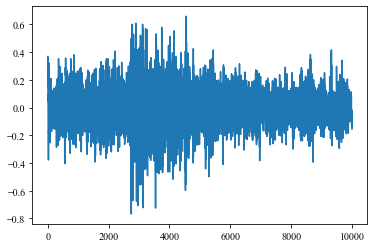

In [197]:
plt.plot(M[5,:10000,2])

In [195]:
datai.keys()

dict_keys([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 'M'])

Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216


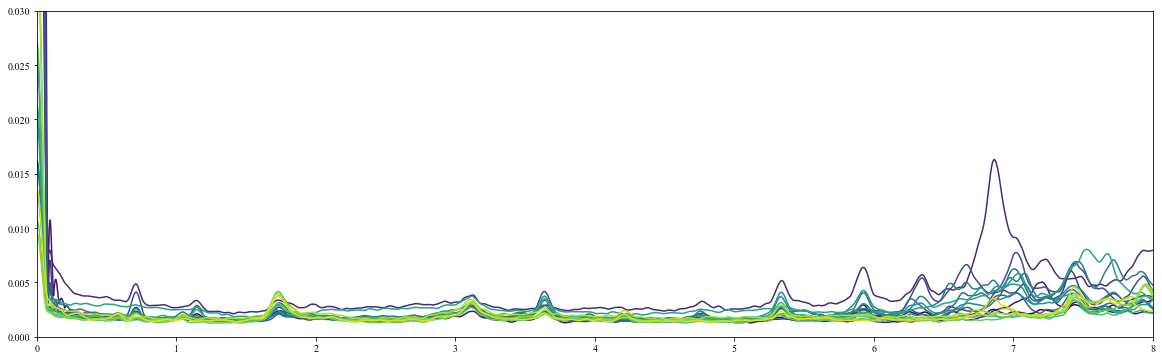

In [277]:
fig,ax = plt.subplots(figsize=(20,6))#,nrows=1,sharex=True)

n = 17
for i,phone in enumerate(datai.keys()):
    t = datai[phone]['tas']
    
    f,TFmoy,fm,Amax = analyse.time_spectrum(ti,M[i,:,0],nt=10000)
    color = colorrr(int(i/n*256))
    ax.plot(f,TFmoy,color=color)
    ax.set_xlim([0,8])
    ax.set_ylim([0,0.03])

    datai[phone]['f']=f
    datai[phone]['TFmoy']=TFmoy

In [211]:
np.diff(f)[0]*50

0.22222716039660378

(0.0, 6.5)

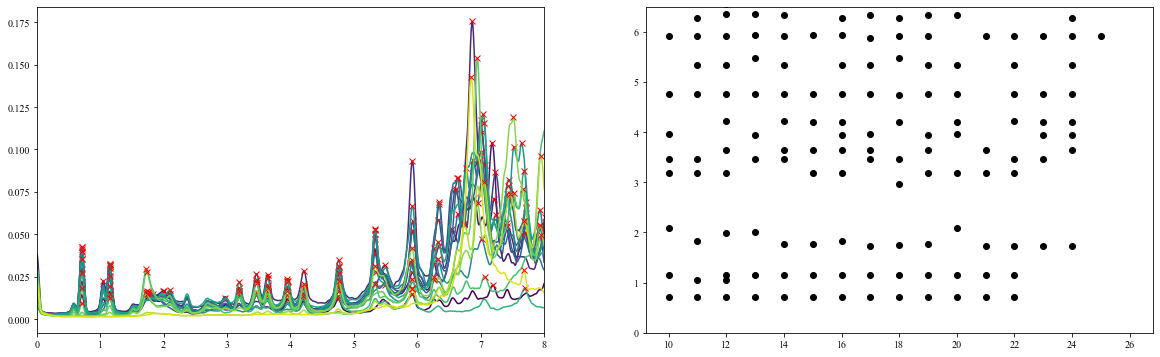

In [247]:
import scipy.signal as sig

fig,axs = plt.subplots(figsize=(20,6),ncols=2)#,sharex=True)

dy = 0.02
for i,phone in enumerate(datai.keys()):

    f = datai[phone]['f']
    TFmoy = datai[phone]['TFmoy']
    
    peaks = sig.find_peaks(TFmoy,distance=5,prominence=0.007)[0]
    peaks = peaks[f[peaks]<20]
    ax = axs[0]
    color = colorrr(int(i/n*256))
    ax.plot(f,TFmoy,color=color)
    ax.plot(f[peaks],TFmoy[peaks],'rx')
    
    ax.set_xlim([0,8])

    ax = axs[1]
    datai[phone]['peaks']=peaks
    npeak = len(peaks)
    ax.plot(phone*np.ones(npeak),f[peaks],'ko')

ax.set_ylim([0,6.5])

In [249]:
f[datai[17]['peaks']]


array([ 0.71112691,  1.14669215,  1.72448276,  3.4667437 ,  3.64008089,
        3.95564346,  4.76010578,  5.33789639,  5.88457521,  6.33791861,
        6.63125847,  6.98237738,  7.24460543,  7.44460987,  7.72017155,
        8.56463476,  9.07575723,  9.28465076, 10.00022222, 10.42689837,
       13.68030399, 15.52478943])

In [269]:
flist = [ 0.71112691,  1.14669215, 3.19118202, 3.4667437, 3.64008089, 3.95119891,  4.20898242,  4.76010578,  5.33345185,  5.92902064]
#flist = [ 0.71112691,  1.14669215, 4.76010578,  5.33345185,  5.92902064]


(array([], dtype=int64),)

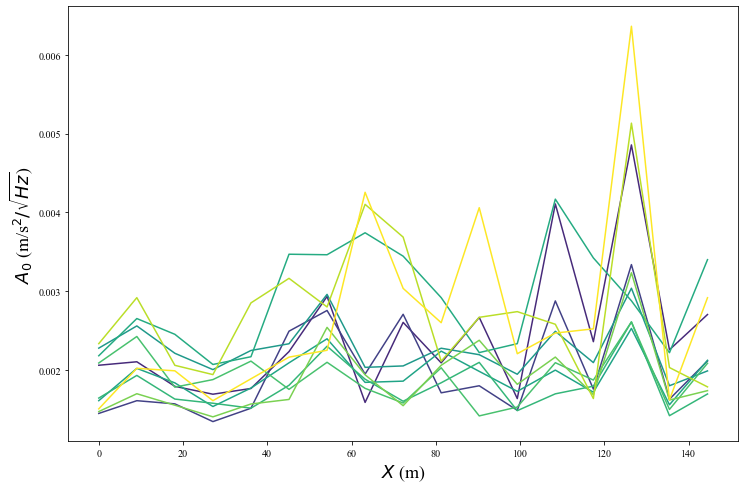

In [279]:
A = np.zeros((n,len(flist)))
for j,fpeak in enumerate(flist):
    for i,phone in enumerate(datai.keys()):
        f = datai[phone]['f']
        ind = np.argmin(np.abs(fpeak-f))
        A[i,j] = datai[phone]['TFmoy'][ind]

fig,ax = plt.subplots(figsize=(12,8))#,nrows=1,sharex=True)

Ls = [datas[phone]['x'] for phone in datas.keys()]
for j,fpeak in enumerate(flist):
    color = colorrr(int(fpeak/np.max(flist)*255))
    ax.plot(Ls,A[:,j],color=color)

figs = graphes.legende('$X$ (m)',r'$A_0$ (m/s$^2/\sqrt{Hz}$)','',ax=ax)

Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216
Number of samples : 216


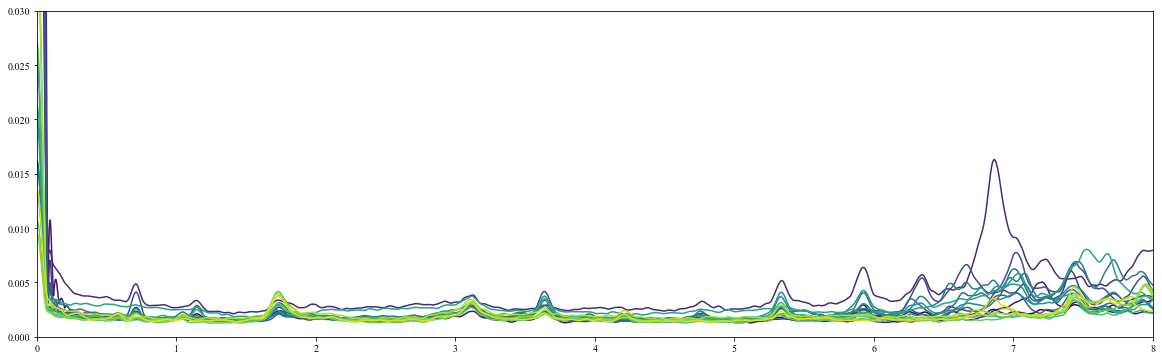

In [275]:
fig,ax = plt.subplots(figsize=(20,6))#,nrows=1,sharex=True)

n = 17
k = 1
for i,phone in enumerate(datai.keys()):
    t = datai[phone]['tas']
    
    f,TFmoy,fm,Amax = analyse.time_spectrum(ti,M[i,:,0],nt=10000)
    color = colorrr(int(i/n*256))
    ax.plot(f,TFmoy,color=color)
    ax.set_xlim([0,8])

    datai[phone]['f']=f
    datai[phone]['TFmoy']=TFmoy

    ax.set_ylim([0,0.03])

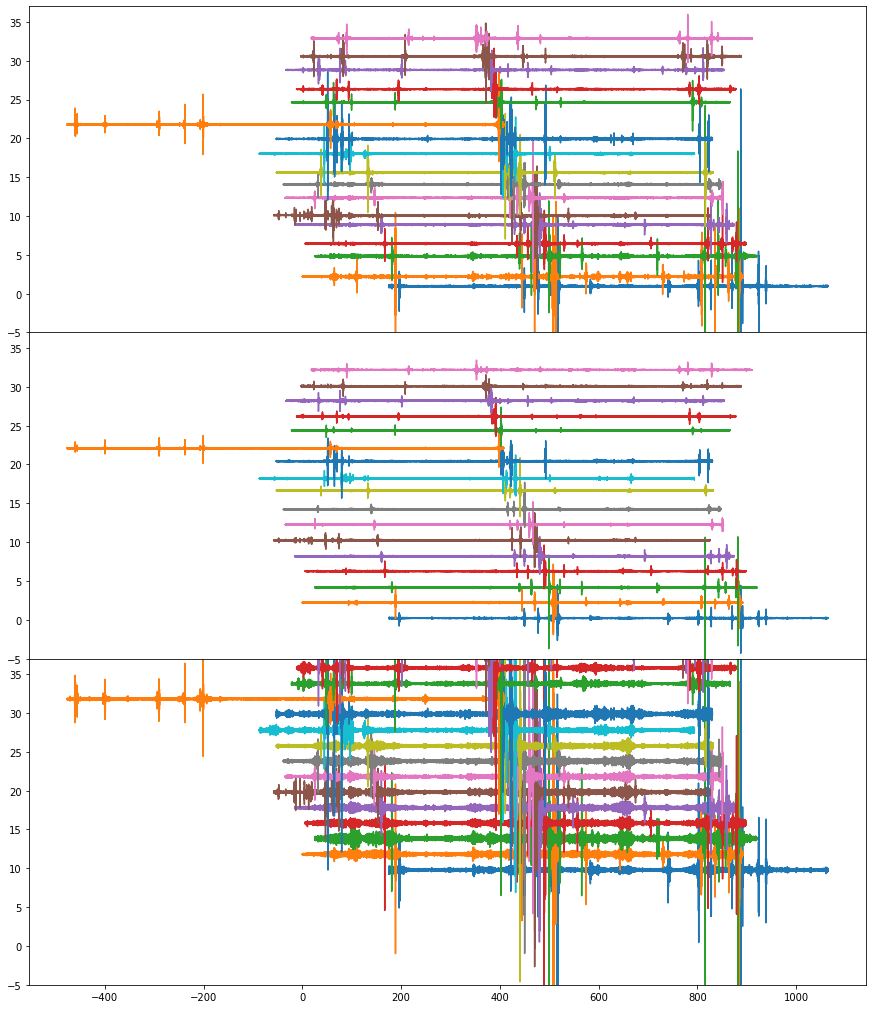

In [57]:
fig,axs = plt.subplots(figsize=(15,3*6),nrows=3,sharex=True)

j0 = 8 #environ 15h50
var = 'a'
for i,phone in enumerate(datas.keys()):
    for key in datas[phone]['d'].keys():
        data = datas[phone]['d'][key]
        t = data['ta']/10**6+datas[phone]['tlag']-t0
        if min(t)<300 and max(t)>300:
            datas[phone]['key']=key
            for c,ax in zip(data['coords'],axs):
                ax.plot(t,data[var+c]+2*i)
                ax.set_ylim([-5,37])

plt.subplots_adjust(hspace=0)


(200.0, 400.0)

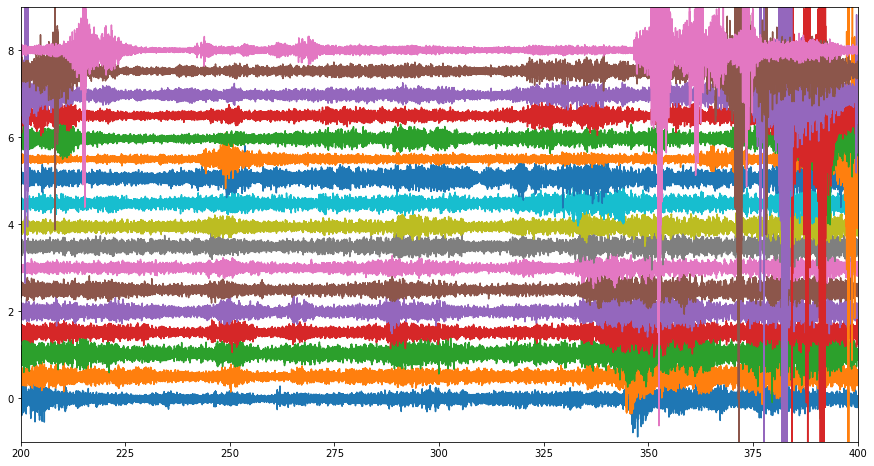

In [68]:
fig,ax = plt.subplots(figsize=(15,8),nrows=1,sharex=True)

g = 9.81
j0 = 8 #environ 15h50
var = 'a'
for i,phone in enumerate(datas.keys()):
    key = datas[phone]['key']
    data = datas[phone]['d'][key]
    t = data['ta']/10**6+datas[phone]['tlag']-t0
    ax.plot(t,data[var+'z']-g+0.5*i)
    ax.set_ylim([-1,9])

ax.set_xlim([200,400])


In [70]:
L*(n-1)/5

27.089999999999996

In [72]:
datas.keys()

dict_keys([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26])

In [127]:
import scipy.interpolate as interp

tmin = 200
tmax = 400

dt = 1/400
ti = np.arange(tmin,tmax,dt)

n = len(datas.keys())
M = np.zeros((n,len(ti),2))

for i,phone in enumerate(datas.keys()):
    key = datas[phone]['key']
    data = datas[phone]['d'][key]
    t = data['ta']/10**6+datas[phone]['tlag']-t0
    az = data[var+'z']-g
    ax = data[var+'x']
    
    fi = interp.interp1d(t,az)
    M[i,:,1]=fi(ti)
    fi = interp.interp1d(t,ax)
    M[i,:,0]=fi(ti)


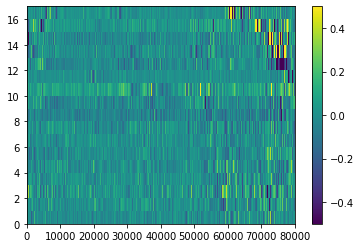

In [81]:
plt.pcolormesh(M,vmin=-0.5,vmax=0.5)
plt.colorbar()

In [82]:
TF = np.abs(np.fft.fftn(M))

In [107]:
datas[phone].keys()

dict_keys(['files', 'x', 'd', 'tlag', 'key'])

In [126]:
0.7*1.5

1.0499999999999998

Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of samples : 8
Number of 

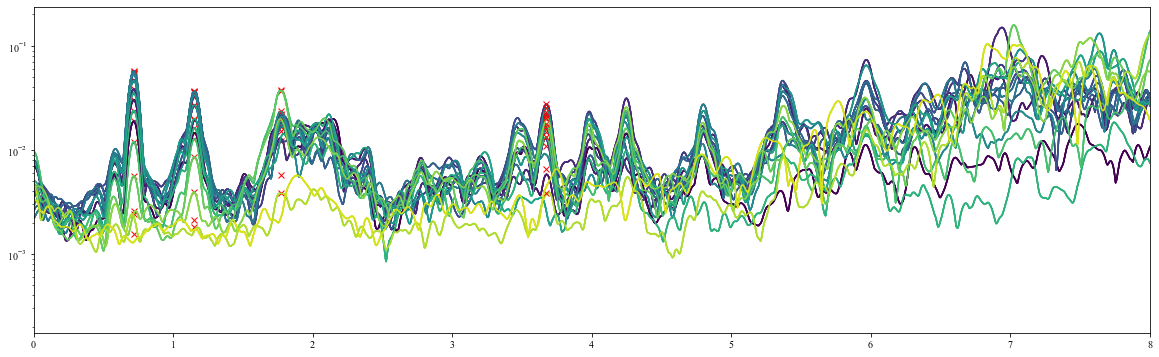

In [148]:
fig,ax = plt.subplots(figsize=(20,6))#,nrows=1,sharex=True)

fmin = 0.65
fmax = 0.9
f0 = 0.73

flist = [0.72,1.15,1.77,3.67]
df = 0.1
k=1
c='z'
for j,f0 in enumerate(flist):
    for i,phone in enumerate(datas.keys()):
        f,TFmoy,fm,Amax = analyse.time_spectrum(t,M[i,:,k],nt=10000)
    
        color = colorrr(int(i/n*256))
        
        ax.plot(f,TFmoy,color=color)
        indices = np.abs(f-f0)<df*f0#np.logical_and(npf>fmin,f<fmax)
        peak = np.max(TFmoy[indices])
        ax.plot(f0,peak,'rx')
        ax.set_xlim([fmin,fmax])
        ax.set_xlim([0,8])
        datas[phone]['A'+c+str(j)]=peak

ax.set_yscale('log')

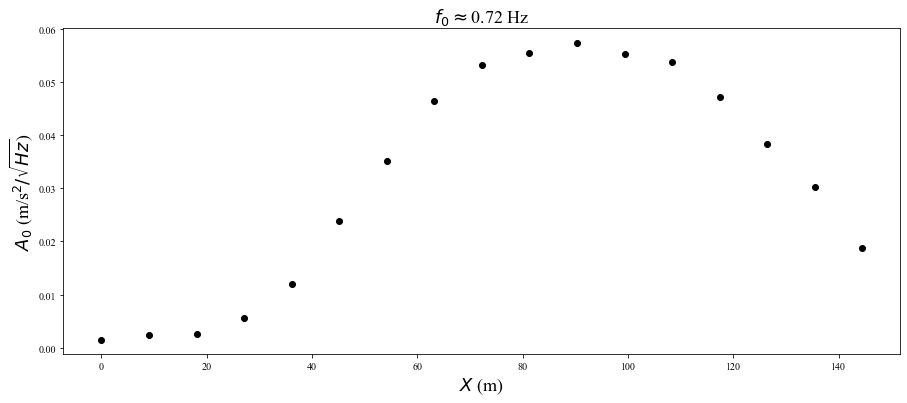

In [145]:
nmode = 2
fig,ax = plt.subplots(figsize=(15,6))#,nrows=nmode,sharex=True)

c = 'z'
j = 0
for phone in datas.keys():
    ax.plot(datas[phone]['x'],datas[phone]['A'+c+str(j)],'ko')

figs = graphes.legende('$X$ (m)',r'$A_0$ (m/s$^2/\sqrt{Hz}$)',r'$f_0 \approx $0.72 Hz',ax=ax)

graphes.save_figs(figs,savedir=savefolder,prefix='Mode0_z_1026')

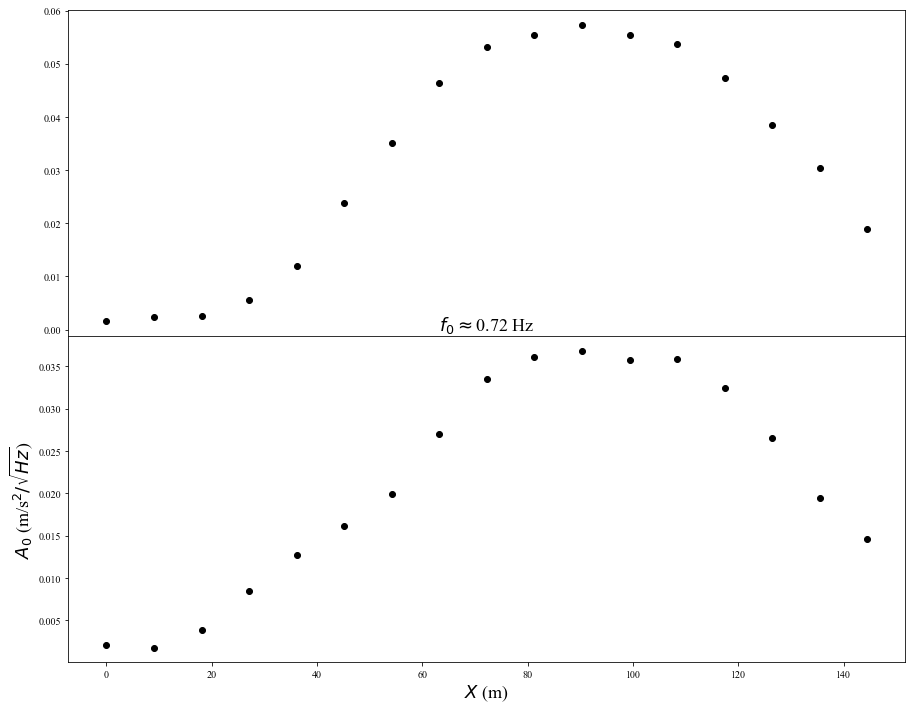

In [143]:
nmode = 2
fig,axs = plt.subplots(figsize=(15,6*nmode),nrows=nmode,sharex=True)

c = 'z'
for j,ax in enumerate(axs):
    for phone in datas.keys():
        ax.plot(datas[phone]['x'],datas[phone]['A'+c+str(j)],'ko')


figs = graphes.legende('$X$ (m)',r'$A_0$ (m/s$^2/\sqrt{Hz}$)',r'$f_0 \approx $0.72 Hz',ax=ax)

plt.subplots_adjust(hspace=0)


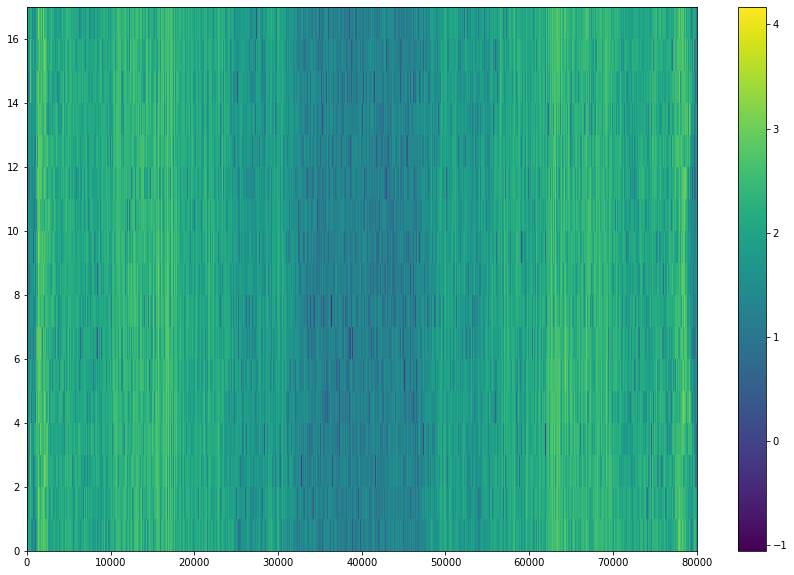

In [84]:
fig,ax = plt.subplots(figsize=(15,10))#,nrows=1,sharex=True)

plt.pcolormesh(np.log10(TF))#,vmin=-0.5,vmax=0.5)
plt.colorbar()

In [93]:
data.keys()

dict_keys(['coords', 'ta', 'ax', 'ay', 'az'])

In [94]:
len(datafiles)

932

In [96]:
import icewave.tools.rw_data as rw
import icewave.phone.load as load_phone

datefmt = '23T13_'

datas = {}
for i,filename in enumerate(datafiles):
    phone = filename.split('/')[-2]
    if not phone in datas.keys():
        datas[phone] = {}
    #print(filename)
    #print(filename.split('/')[-1].split(datefmt)[1])
    
#    typ = filename.split('/')[-1].split(datefmt)[1].split('-')[0]
    try:
        key = int(filename.split('/')[-1].split('-')[-3])
        print(i,phone,key)
        data = load_phone.load_gobfile(filename,var='a')
    #    data = rw.read_csv(filename)
        datas[phone][key]=data
    except:
        print(f'cannot read {os.path.basename(filename)}')

0 1 1
1 1 6
2 1 5
3 1 4
4 1 3
5 1 2
6 7 10
7 7 2
8 7 3
9 7 6
cannot read 2022-04-06T10_10_14-android-sensor-accelerometer-6-6710581215-7601985101.csv
10 7 13824909320
11 7 13
12 7 9
13 7 5
cannot read 2022-04-06T10_10_14-android-sensor-accelerometer-5-5819455927-6710578739.csv
14 7 12
15 7 7
16 7 1
17 7 8
18 7 11
19 7 4
20 39 12
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-12-12039199849-12937938067.csv
21 39 10
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-10-10241875585-11140473238.csv
22 39 2
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-2-3045420587-3945594272.csv
23 39 8
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-8-8444824770-9343394606.csv
24 39 4
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-4-4845896861-5746004896.csv
25 39 7
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-7-7545985528-8444822274.csv
26 39 6
27 39 1
cannot read 2025-10-23T13_27_52-android-sensor-accelerometer-1-214517416

[40  0  4 33 12 43 42 18 49 34 52 51  8 38 26 11 30 15 62 60 59 20 53 54
 57 56 55 27 39 58  2  3 10 47 35 50 14 32 25 31 61 22 46  7 28 41 45 23
 37 13 21 29 48 44 17 36  6 19  5  1 24  9 16]


(0.0, 25.0)

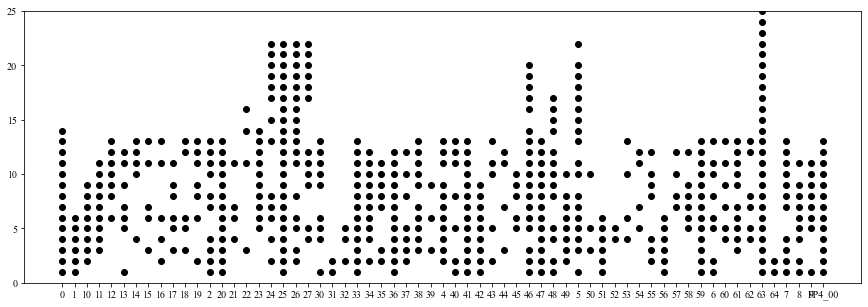

In [107]:
N = []
fig,ax = plt.subplots(figsize=(15,5))
phonelist = np.asarray(list(datas.keys()))[indices]

for phone in phonelist:
    for key in datas[phone].keys():
        ax.plot(phone,int(key),'ko')     
        
    N.append(len(list(datas[phone].keys())))

indices = np.argsort(list(datas.keys()))
print(indices)
Ns = np.asarray(N)[indices]

#ax.plot(phonelist,Ns,'rs')
ax.set_ylim([0,25])

In [91]:
print(datas.keys())

dict_keys([1, 6, 5, 4, 3, 2, 10, 13824909320, 13, 9, 12, 7, 8, 11, 15385717363721, 3132195153066, 3139915047050, 12425690747, 21613426165, 23137650468, 16, 14, 3140819731399, 14111863028, 15, 17, 22, 10288645390574, 21, 19, 18, 20, 23104907366, 78, 65, 54, 44, 58, 89, 59, 46, 24, 73, 63, 68, 23, 87, 71, 48, 37, 42, 82, 60, 64, 30, 84, 92, 74, 86, 39, 51, 93, 33, 38, 31, 56, 28, 29, 35, 26, 75, 62, 66, 41, 50, 77, 43, 85, 91, 90, 72, 67, 25, 49, 79, 76, 55, 27, 61, 94, 81, 53, 95, 32, 47, 70, 88, 57, 80, 45, 69, 52, 40, 83, 36, 34, 9777065079930, 12071409271, 13307444427, 22844007927, 14090588674, 3141190622485, 23128803921, 22806509233, 9952293157892, 13544324793, 183040761574, 183231953627, 183076780178, 184060893811, 1045015137414, 183809690165, 184151098881, 254966198876, 3139144819328, 5624047672912, 22724347723, 526832933022, 11685920210, 23031568614, 11890072403, 11725452201, 22879610143, 3133091526580, 3132841503831, 13318488081904, 12918215267, 3119349890374, 22420355361, 10288

In [25]:
datas[7].keys()

dict_keys(['coords', 'ta', 'ax', 'ay', 'az', 'tm', 'mx', 'my', 'mz', 'tg', 'gx', 'gy', 'gz'])

10


KeyError: 'ta'

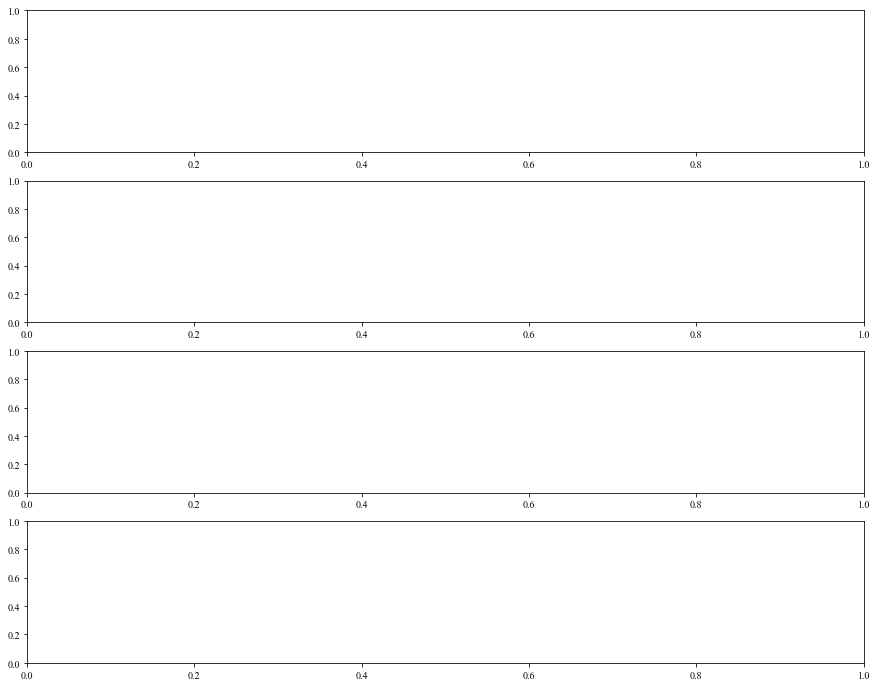

In [46]:
n0 = 9
n = len(datas.keys())-n0
fig,axs = plt.subplots(figsize=(15,3*n),nrows=n)
var = 'a'
for i,(key,ax) in enumerate(zip(range(n0+1,n0+n+1),axs)):
    print(key)
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6
    c = 'y'
#    for c in data['coords']:
    y = data[var+c]
    y = y-np.mean(y)
    ax.plot(t,y)

    ax.set_ylim([-0.03,0.03])
    #ax.set_xlim([100,140])

7
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17


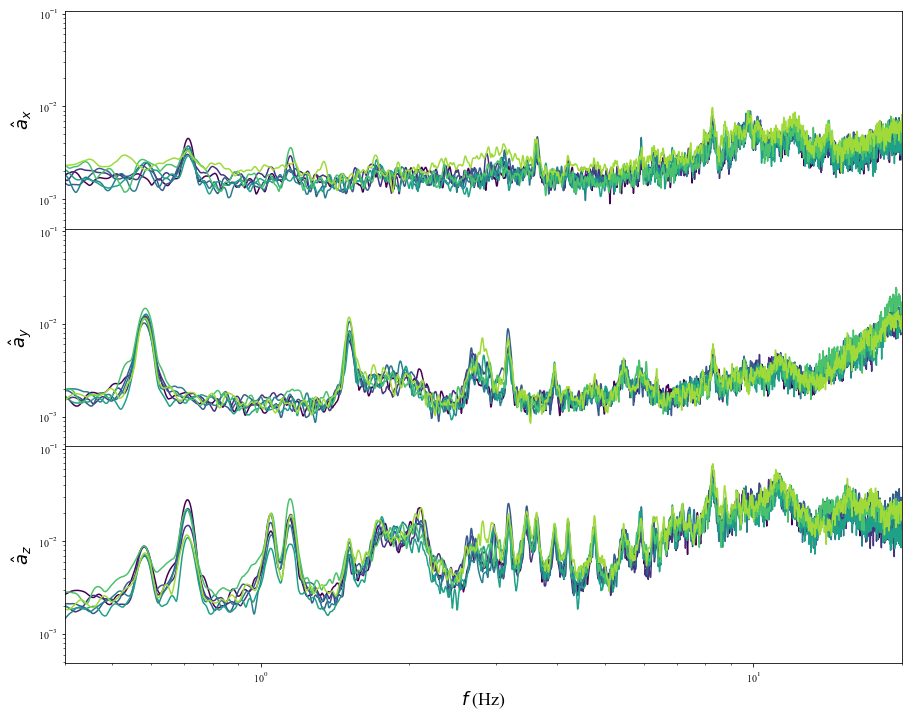

In [33]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 2
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'a'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=20000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
    #    ax.set_ylim([-0.3,0.3])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
#graphes.save_figs(figs,savedir=savefolder,prefix='10A_10_Spectrum_3C')


       

7
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18


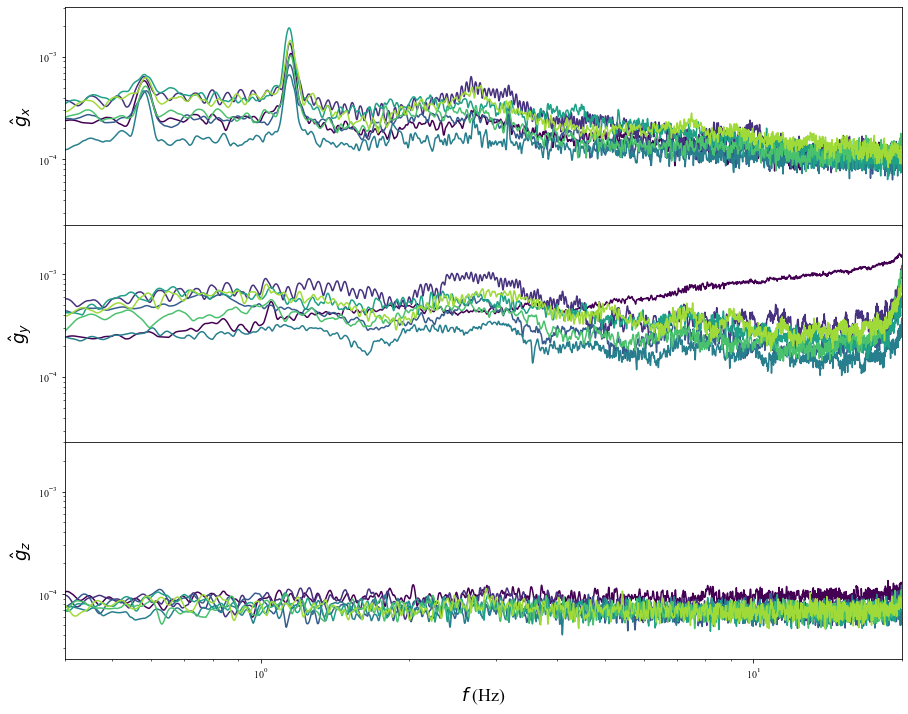

In [89]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'g'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=20000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
        #ax.set_ylim([0.05,0.5])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
#graphes.save_figs(figs,savedir=savefolder,prefix='FP_00_Spectrum_3C')


       

7
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17


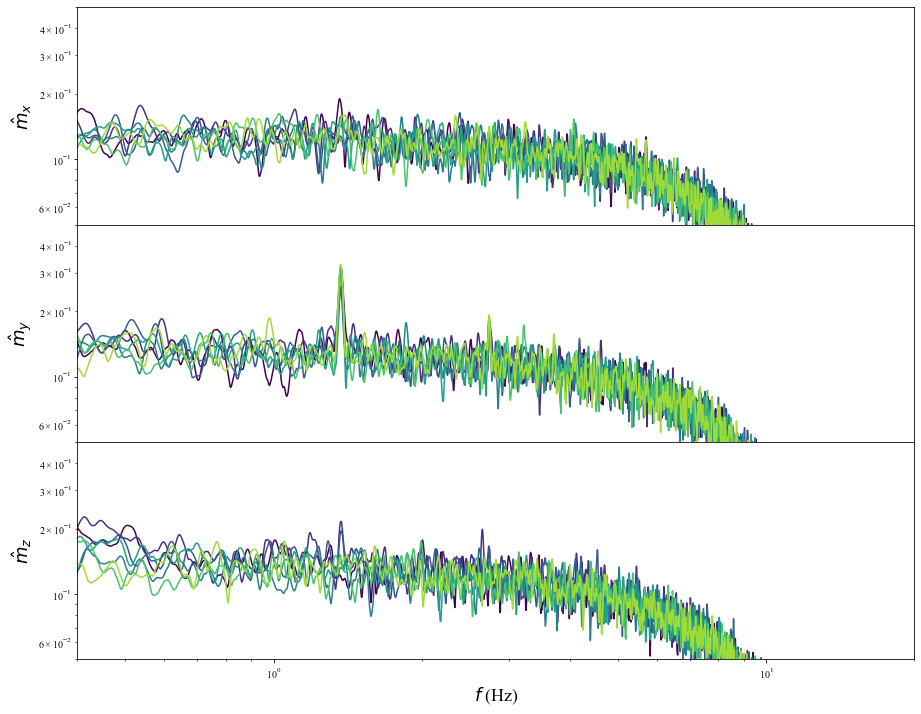

In [87]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'm'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=5000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
        ax.set_ylim([0.05,0.5])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
#graphes.save_figs(figs,savedir=savefolder,prefix='FP_00_Spectrum_3C')


       

a
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Accelerometer.csv
g
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Gyroscope.csv
l
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Location.csv
m
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Magnetometer.csv


In [13]:
print(data.keys())

dict_keys(['gy', 'gx', 'gz', 'tg', 'ay', 'ax', 'az', 'ta', 'my', 'mx', 'mz', 'tm', 'loc'])


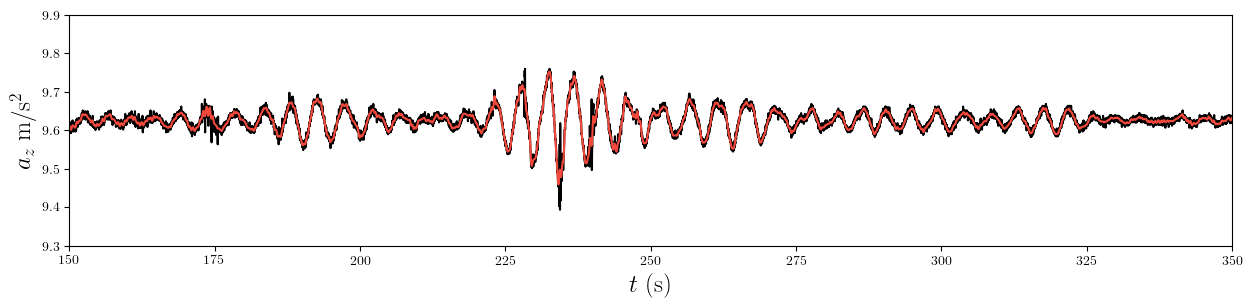

In [46]:
plt.subplots(figsize=(15,3))
#data['a']
plt.plot(data['ta'],data['az'],'k')
plt.xlim([150,350])
plt.ylim([9.3,9.9])
figs = graphes.legende('$t$ (s)','$a_z$ m/s$^2$','')


[b,a] = sig.butter(6,0.1,'low')
az_f =  sig.filtfilt(b,a,data['az'])


'#F4AD3C'
plt.plot(data['ta'],az_f,color=(244/256,73/256,60/256))

graphes.save_figs(figs,savedir=savefolder,overwrite=True)

dict_keys(['a', 'g', 'l', 'm'])
['0.0' '0.0' '0.1940502822' ... '0.0' '0.0' '0.0']


(9.25, 10.5)

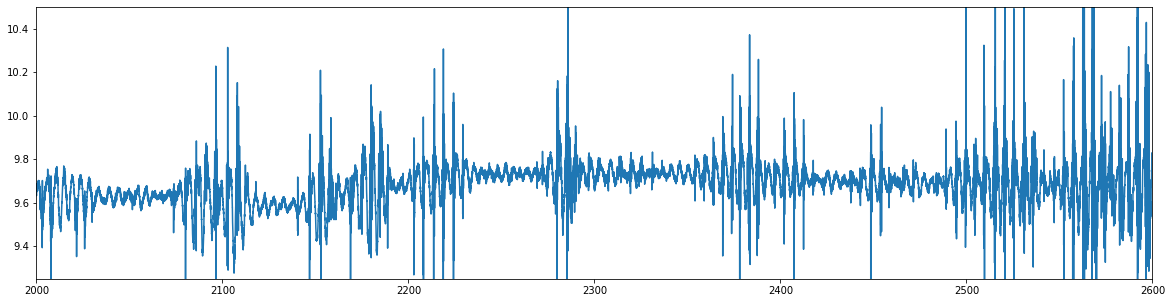

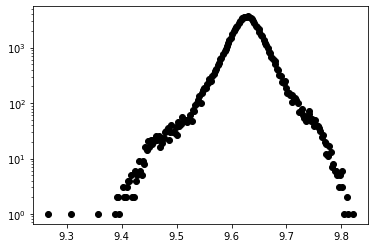

In [79]:
[n,x] = np.histogram(data['a']['d'][:,3][5000:100000],500)

xc = (x[1:]+x[:-1])/2

plt.plot(xc-x0,n,'ko')
plt.yscale('log')


In [12]:
folderlist = glob.glob(folder+'/*/')

data = {}
for fold in folderlist:
    print(fold)
    d,key = phone.read_data(fold)

/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_01_Accelero_Gyro_Magneto_GPS 2024-02-10_19-10-30/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_04_192_168_0_104/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_06_Accelero_Gyro_Magneto_GPS 2024-02-10_18-55-25/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_07_Accelero_Gyro_Magneto_GPS 2022-04-10_11-00-32/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_08_Accelero_Gyro_Magneto_GPS 2024-02-10_18-38-02/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_09_Accelero_Gyro_Magneto_GPS 2024-02-10_18-40-35/
/Users/stephane/Documents/git/icewave/icew